# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar el trabajo en la presente notebook.
*   Alumno 1: Emma Oitaven Carracedo
*   Alumno 2: Ramiro Rivas Fernández
*   Alumno 3: Víctor Rodríguez Rodríguez
*   Alumno 4: Nicolás Zamorano Ramírez






---
## **PARTE 1** - Instalación y requisitos previos
---

### Pasos que hemos seguido en local

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. A continuación se muestran las instrucciones  del proceso de configuración del entorno de trabajo en local con Windows + Miniconda + VS Code.

Hemos creado un environment de conda con Python 3.8 e instalado las librerías pertinentes.

```bash
# 1) Crear environment con Python 3.8 (requerido por gym 0.17.3)
conda create --name miar_rl python=3.8 -y
conda activate miar_rl

# 2) Herramientas base
python -m pip install --upgrade pip setuptools wheel

# 3) TensorFlow
pip install tensorflow==2.5.3

# 4) Dependencias compatibles
pip install numpy==1.19.5 h5py==3.1.0 Pillow==9.5.0 pyglet==1.5.0
pip install gym==0.17.3
pip install imageio imageio-ffmpeg

# 5) keras-rl2 sin dependencias
pip install --no-deps keras-rl2==1.0.5

# 6) Kernel para VS Code
pip install ipykernel
python -m ipykernel install --user --name miar_rl --display-name "Python (miar_rl)"
```
---


## **PARTE 2**. Enunciado
---
Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondiente de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.
---

## **PARTE 3**. Desarrollo y preguntas
---

#### Importar librerías

In [ ]:
# Importación de todas las librerías usadas durante el proyecto

# Librerías estándar
import os
import time
import json
import sys

# Cálculo numérico y visualización
import numpy as np
import gym
import matplotlib.pyplot as plt
import matplotlib as mpl

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# keras-rl2 (algoritmo DQN)
from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint, Callback

# Generación de GIFs y visualización de resultados
import imageio
from PIL import Image, ImageDraw, ImageFont

# Utilidades
from importlib.metadata import version

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
# Comprobación del entorno y dependencias
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Keras (tf.keras) version:", tf.keras.__version__)
print("keras-rl2:", version("keras-rl2"))
print("gym:", version("gym"))
print("numpy:", version("numpy"))

Python: 3.8.20
TensorFlow: 2.5.3
Keras (tf.keras) version: 2.5.0
keras-rl2: 1.0.5
gym: 0.17.3
numpy: 1.19.5


#### Configuración base

In [3]:
# Configuración base para Acrobot-v1
env_name = 'Acrobot-v1'
env = gym.make(env_name)

# Semillas para reproducibilidad (NumPy, TensorFlow y entorno)
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)
env.seed(SEED)

# Parámetros del entorno
INPUT_SHAPE = env.observation_space.shape
WINDOW_LENGTH = 1 # 1 único estado por observación
nb_actions = env.action_space.n # acciones disponibles

print(f"Entorno: {env_name}")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acciones: {env.action_space} - {nb_actions} acciones")
print(f"INPUT_SHAPE: {INPUT_SHAPE}, WINDOW_LENGTH: {WINDOW_LENGTH}")

Entorno: Acrobot-v1
Espacio de observación: Box(-28.274333953857422, 28.274333953857422, (6,), float32)
Espacio de acciones: Discrete(3) - 3 acciones
INPUT_SHAPE: (6,), WINDOW_LENGTH: 1


In [ ]:
class AcrobotProcessor(Processor):
    #Procesador de las observaciones de Acrobot-v1.
    
    # Valores máximos de las velocidades angulares
    THETA1_DOT_MAX = 4 * np.pi
    THETA2_DOT_MAX = 9 * np.pi

    def process_observation(self, observation):
        assert observation.shape == (6,)
        obs = np.asarray(observation, dtype=np.float32).copy()

        # Normalizar las velocidades angulares
        obs[4] /= self.THETA1_DOT_MAX
        obs[5] /= self.THETA2_DOT_MAX

        return obs

    def process_state_batch(self, batch):
        # Aseguramos dtype float32 para el modelo Keras
        return batch.astype('float32')

### Búsqueda manual de hiperparámetros sobre el baseline

Antes de hacer una comparativa entre las diferentes variantes de DQN, se ha realizado una búsqueda manual de hiperparámetros sobre la configuración **DQN baseline**. Se han empleado 5 combinaciones de hiperparámetros con el objetivo de acercar su recompensa media al umbral de **-100** (resuelto).

La búsqueda se centra en evaluar distintas combinaciones de cuatro parámetros que tienen un impacto importante en el entrenamiento:

- **Tamaño de red** (`hidden_size`): 64 vs 128 neuronas por capa oculta.
- **Learning rate** del optimizador Adam.
- **Batch size** para la actualización por replay.
- **Número de pasos de entrenamiento**.

En cada trial se cambia solo uno de estos parámetros respecto a la configuración base, de forma que se pueda observar el efecto de cada modificación. La comparación se realiza por pares: `B0 vs B1` mide el efecto puro de aumentar la red; `B0 vs B2` el efecto puro de aumentar los pasos, etc.

Todos los experimentos emplean la misma semilla que en el resto del proyecto (`SEED=123`) para mantener unas condiciones de entrenamiento comparables.

In [ ]:
# Búsqueda de hiperparámetros
LOG_DIR = 'logs'
WEIGHTS_DIR = 'weights'
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs('plots', exist_ok=True)

def build_q_model_flex(input_shape, nb_actions, window_length=1, hidden_size=64):
    # Igual que la función build_q_model pero con tamaño de capa configurable. Mantiene la restricción de que layers[-2] sea la última capa densa de features.
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(hidden_size, activation='relu')) # 2 capas con activación relu y una linear que devuelve la estimación de Q 
    model.add(Dense(nb_actions, activation='linear'))
    return model


def build_agent_flex(model, processor, learning_rate=1e-3, batch_size=64):
    # DQNAgent baseline con LR y batch_size configurables. El resto de hiperparámetros se mantienen fijos en los valores del experimento principal para que la comparación sea justa.
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    policy = LinearAnnealedPolicy( # se setea el annealing de epsilon (decrece en cada step nb_steps=10000)
        EpsGreedyQPolicy(), attr='eps',
        value_max=1.0, value_min=0.05, value_test=0.0, nb_steps=10000
    )
    dqn = DQNAgent(
        model=model, nb_actions=nb_actions, memory=memory, processor=processor,
        policy=policy, nb_steps_warmup=1000, gamma=0.99,
        target_model_update=1e-2, train_interval=4, batch_size=batch_size,
        enable_double_dqn=False, enable_dueling_network=False,
    )
    dqn.compile(Adam(learning_rate=learning_rate), metrics=['mae'])
    return dqn


def evaluate_trial(dqn, seed=123, n_episodes=100):
    # Evaluación de un agente sobre n_episodes. Greedy sin exploración.

    # Ejecuta el agente en modo test y recoge las recompensas. 
    env_eval = gym.make(env_name)
    env_eval.seed(seed)
    np.random.seed(seed)
    hist = dqn.test(env_eval, nb_episodes=n_episodes, visualize=False, verbose=0)
    rewards = np.array(hist.history['episode_reward'])
    env_eval.close()
    return {
        'mean_reward': float(rewards.mean()),
        'std_reward': float(rewards.std()),
        'min_reward': float(rewards.min()),
        'max_reward': float(rewards.max()),
        'solved': int(np.sum(rewards > -500)), # cuenta cuantos episodios alcanzan la meta antes del límite de pasos. 
    }


def run_trial(name, hidden_size, learning_rate, batch_size, nb_steps, seed=123):
    # Entrena y evalúa un trial. Devuelve dict con métricas y guarda log en formato json.
    print(f"\n--- Trial: {name} ---")
    print(f"  hidden={hidden_size}, lr={learning_rate}, batch={batch_size}, steps={nb_steps}")
    
    # Control de semillas (idéntico a train_config)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    env_local = gym.make(env_name)
    env_local.seed(seed)
    
    # Construir modelo y agente con los hiperparámetro del trial
    model = build_q_model_flex(INPUT_SHAPE, nb_actions, WINDOW_LENGTH, hidden_size)
    processor = AcrobotProcessor()
    dqn = build_agent_flex(model, processor, learning_rate, batch_size)
    
    # Log a fichero propio del trial 
    log_path = os.path.join(LOG_DIR, f'search_{name}_log.json')
    callbacks = [FileLogger(log_path, interval=100)]
    
    t0 = time.time() 
    dqn.fit(env_local, nb_steps=nb_steps, callbacks=callbacks, # Entrena el agente y mide cuánto tarda. 
            log_interval=max(nb_steps // 5, 10000),
            visualize=False, verbose=1)
    train_time = time.time() - t0
    env_local.close()
    
    # Evaluar sobre 100 episodios de test
    metrics = evaluate_trial(dqn, seed=seed)
    metrics.update({
        'name': name, 'train_time': train_time,
        'hidden_size': hidden_size, 'learning_rate': learning_rate,
        'batch_size': batch_size, 'nb_steps': nb_steps,
    })
    print(f"  -> reward = {metrics['mean_reward']:+.1f} +/- {metrics['std_reward']:.1f}, "
          f"solved = {metrics['solved']}/100, "
          f"time = {train_time:.0f}s")
    return metrics

In [ ]:
# 5 trials buscando el mejor hiperparámetro, diseñados para aislar el efecto de cada hiperparámetro. 
# (B0 vs B1): efecto puro de red mayor (64 -> 128)
# (B0 vs B2): efecto puro de más pasos (100k -> 200k)
# (B1 vs B4): efecto del batch mayor + pasos
# B3: LR menor con red y batch mayores 
# B4: combinación "todo mejor" 
TRIALS = [
    {'name': 'B0_baseline', 'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000}, 
    {'name': 'B1_red_grande', 'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000},
    {'name': 'B2_mas_pasos', 'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 200000},
    {'name': 'B3_learning_rate', 'hidden_size': 128, 'learning_rate': 5e-4, 'batch_size': 64, 'nb_steps': 150000},
    {'name': 'B4_todo_mejor', 'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 64, 'nb_steps': 200000},
]

# Ejecutar todos los trials
search_results = []
for trial in TRIALS:
    metrics = run_trial(**trial)
    search_results.append(metrics) # se guarda las métricas 

# Resumen ordenado por reward medio 
print("\n" + "="*80)
print("RESUMEN DE LA BÚSQUEDA (ordenado por reward medio):")
print("="*80)
print(f"{'Trial':<20s} {'reward':>12s} {'std':>7s} {'solved':>9s} {'time':>7s}")
print("-"*80)
for r in sorted(search_results, key=lambda r: -r['mean_reward']):
    print(f"  {r['name']:<20s}  {r['mean_reward']:+8.1f}  {r['std_reward']:6.1f}  "
          f"{r['solved']:>4d}/100  {r['train_time']:>5.0f}s")

# Identificar, guardar e imprimir el mejor conjunto de hiperparámetros
best_trial = max(search_results, key=lambda r: r['mean_reward'])
print(f"\n[MEJOR] {best_trial['name']}: reward = {best_trial['mean_reward']:+.1f}, "f"solved = {best_trial['solved']}/100")
print(f"Hiperparámetros ganadores: hidden={best_trial['hidden_size']}, "
      f"lr={best_trial['learning_rate']}, batch={best_trial['batch_size']}, "
      f"steps={best_trial['nb_steps']}")


--- Trial: B0_baseline ---
  hidden=64, lr=0.001, batch=32, steps=100000
Training for 100000 steps ...
Interval 1 (0 steps performed)
  442/20000 [..............................] - ETA: 6s - reward: -1.0000

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


20000/20000 [==============================] - 17s 854us/step - reward: -1.0000
40 episodes - episode_reward: -500.000 [-500.000, -500.000] - loss: 0.494 - mae: 12.656 - mean_q: -18.750 - mean_eps: 0.252

Interval 2 (20000 steps performed)
20000/20000 [==============================] - 18s 882us/step - reward: -0.9999
40 episodes - episode_reward: -496.075 [-500.000, -397.000] - loss: 2.055 - mae: 30.045 - mean_q: -44.631 - mean_eps: 0.050

Interval 3 (40000 steps performed)
20000/20000 [==============================] - 18s 888us/step - reward: -0.9994
43 episodes - episode_reward: -464.395 [-500.000, -173.000] - loss: 3.354 - mae: 39.565 - mean_q: -58.782 - mean_eps: 0.050

Interval 4 (60000 steps performed)
20000/20000 [==============================] - 18s 905us/step - reward: -0.9968
71 episodes - episode_reward: -282.592 [-500.000, -98.000] - loss: 4.173 - mae: 44.039 - mean_q: -65.330 - mean_eps: 0.050

Interval 5 (80000 steps performed)
20000/20000 [============================

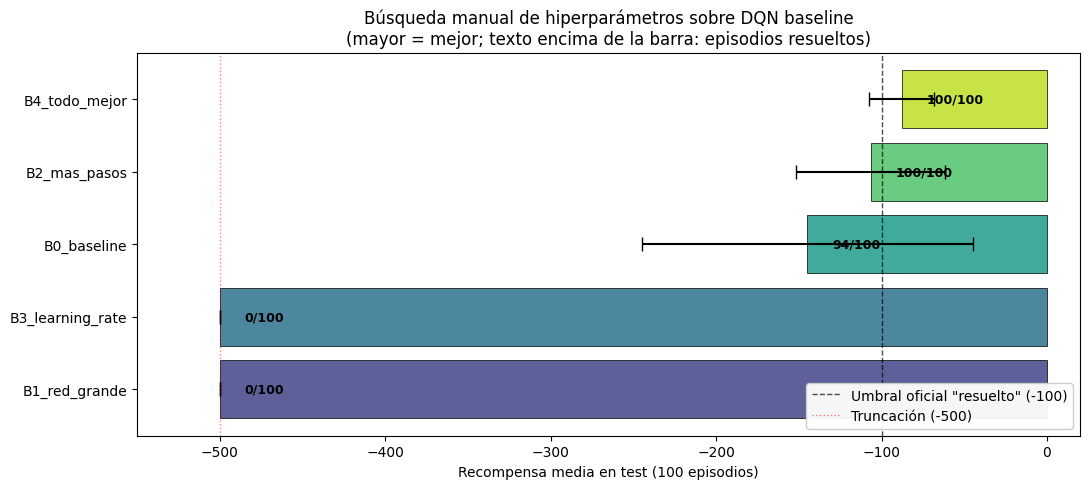

In [ ]:
# Gráfica comparativa de trials de la búsqueda de hiperparámetros
fig, ax = plt.subplots(figsize=(11, 5))

# Ordenar por reward medio (mejor arriba)
results_sorted = sorted(search_results, key=lambda r: r['mean_reward'])
names   = [r['name'] for r in results_sorted]
rewards = [r['mean_reward'] for r in results_sorted]
stds    = [r['std_reward'] for r in results_sorted]
solved  = [r['solved'] for r in results_sorted]

# Colormap discreto
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_sorted)))
bars = ax.barh(names, rewards, xerr=stds, color=colors, alpha=0.85, edgecolor='black', linewidth=0.6, capsize=5)

# Líneas de referencia
ax.axvline(-100, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Umbral oficial "resuelto" (-100)')
ax.axvline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Truncación (-500)')

# Anotar cada barra con nº de episodios resueltos
for bar, r, s in zip(bars, rewards, solved):
    ax.text(min(r + 15, -20), bar.get_y() + bar.get_height()/2,f'{s}/100', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recompensa media en test (100 episodios)')
ax.set_title('Búsqueda manual de hiperparámetros sobre DQN baseline\n'
             '(mayor = mejor; texto encima de la barra: episodios resueltos)')
ax.set_xlim(-550, 20)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig('plots/04_hp_search.png', dpi=120, bbox_inches='tight') # guarda la gráfica en la carpeta plots
plt.show()

1. Implementación de la red neuronal

In [ ]:
def build_q_model(input_shape, nb_actions, window_length=1):
    # Construye la red Q(s, a) para Acrobot. Arquitectura MLP 6 -> 128 -> 128 -> 3 con activaciones ReLU.
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))   # layers[-2]: features para Dueling
    model.add(Dense(nb_actions, activation='linear'))  # layers[-1]: Q-valores
    return model

# Verificación de la arquitectura. Usamos una semilla aislada (99) para que esta demo no consuma la aleatoriedad de TF que luego usarán los entrenamientos.
tf.random.set_seed(99)
_demo_model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)

print(_demo_model.summary())
print(f"\nlayers[-2] = {_demo_model.layers[-2].name} (output shape: {_demo_model.layers[-2].output_shape})")
del _demo_model

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 6)                 0         
_________________________________________________________________
dense_15 (Dense)             (None, 128)               896       
_________________________________________________________________
dense_16 (Dense)             (None, 128)               16512     
_________________________________________________________________
dense_17 (Dense)             (None, 3)                 387       
Total params: 17,795
Trainable params: 17,795
Non-trainable params: 0
_________________________________________________________________
None

layers[-2] = dense_16 (output shape: (None, 128))


2. Implementación de la solución DQN

In [ ]:
def build_agent(model, processor, enable_double_dqn=False, enable_dueling_network=False, dueling_type='avg'):
    
    # Construye un DQNAgent configurable.
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    
    policy = LinearAnnealedPolicy(
        EpsGreedyQPolicy(),
        attr='eps',
        value_max=1.0, # Exploración inicial total
        value_min=0.05, # Exploración residual al final
        value_test=0.0, # Greedy puro en test
        nb_steps=10000 # Decaimiento lineal durante los primeros 10k steps
    )
    
    dqn = DQNAgent(
        model=model,
        nb_actions=nb_actions,
        memory=memory,
        processor=processor,
        policy=policy,
        nb_steps_warmup=1000,
        gamma=0.99,
        target_model_update=1e-2, # Soft update
        train_interval=4,
        batch_size=64,
        enable_double_dqn=enable_double_dqn,
        enable_dueling_network=enable_dueling_network,
        dueling_type=dueling_type,
    )
    
    dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])
    return dqn

In [ ]:
NB_TRAIN_STEPS = 200000   # Ajustado según búsqueda de hiperparámetros - Trial B4
CHECKPOINT_INTERVAL = 40000   # Cada cuántos pasos se guarda un snapshot del modelo


class BestCheckpointCallback(Callback):
    # Callback que evalua el agente cada 40000 pasos y guarda los pesos si superan al mejor resultado observado hasta el momento.

    def __init__(self, filepath, env_name, interval=40000, n_eval=30, seed=456):
        super().__init__()
        self.filepath = filepath
        self.env_name = env_name
        self.interval = interval
        self.n_eval = n_eval
        self.seed = seed
        self.best_reward = -np.inf
        self.next_check_at = interval
        self.step_count = 0
    
    def on_step_end(self, step, logs=None):
        self.step_count += 1
        if self.step_count < self.next_check_at:
            return
        self.next_check_at += self.interval
        
        # Evaluación rápida con predicción greedy directa desde la red (evita interferir con el estado interno del agente durante el entrenamiento)
        env_eval = gym.make(self.env_name)
        env_eval.seed(self.seed)
        
        rewards = []
        for ep in range(self.n_eval):
            obs = env_eval.reset()
            total = 0.0
            for _ in range(500):
                # Aplicar el processor (normalización) igual que en entrenamiento
                proc_obs = self.model.processor.process_observation(obs) if self.model.processor else obs
                batch = np.array([[proc_obs]]).astype('float32')
                q_values = self.model.model.predict(batch, verbose=0)[0]
                action = int(np.argmax(q_values))
                obs, r, done, _ = env_eval.step(action)
                total += r
                if done:
                    break
            rewards.append(total)
        env_eval.close()
        
        mean_reward = float(np.mean(rewards))
        
        if mean_reward > self.best_reward:
            self.best_reward = mean_reward
            self.model.save_weights(self.filepath, overwrite=True)
            print(f"\n[BEST @ paso {self.step_count}] reward = {mean_reward:+.1f} — guardado")
        else:
            print(f"\n[paso {self.step_count}] reward = {mean_reward:+.1f} (mejor sigue siendo {self.best_reward:+.1f})")


def train_config(config_name, **agent_kwargs):
    # Entrenar una configuración de DQN sobre Acrobot-v1.
    print(f"\n{'='*60}\n  Entrenando configuración: {config_name}\n{'='*60}")
    
    SEED = 123
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    env_local = gym.make(env_name)
    env_local.seed(SEED)
    
    # Cada config construye su propia red
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    log_filename = os.path.join(LOG_DIR, f'dqn_{config_name}_log.json')
    weights_filename = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_weights.h5f')
    best_filename = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_best.h5f')

    # Patrón con {step} para que keras-rl reemplace el número de paso al guardar
    ckpt_pattern = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{{step}}.h5f')
    
    callbacks = [
        FileLogger(log_filename, interval=100),
        ModelIntervalCheckpoint(ckpt_pattern, interval=CHECKPOINT_INTERVAL),
        BestCheckpointCallback(best_filename, env_name, interval=CHECKPOINT_INTERVAL),
    ]
    
    history = dqn.fit(env_local, nb_steps=NB_TRAIN_STEPS, callbacks=callbacks,
                      log_interval=10000, visualize=False, verbose=1)
    
    # Guardar los pesos finales
    dqn.save_weights(weights_filename, overwrite=True)
    
    # Cargar el mejor checkpoint (best snapshot) en el dqn en memoria, para que la evaluación posterior use el mejor modelo, no el último.
    if os.path.exists(best_filename + '.index'):
        dqn.load_weights(best_filename)
        print(f"\n[BEST] Modelo restaurado desde {best_filename}")
    else:
        print(f"\n[WARN] No hay best checkpoint; se usan los pesos finales.")
    
    print(f"Pesos finales guardados en {weights_filename}")
    print(f"Mejor checkpoint guardado en {best_filename}")
    print(f"Log guardado en {log_filename}")
    print(f"Snapshots intermedios en {WEIGHTS_DIR}/dqn_{config_name}_ckpt_*.h5f")
    
    return dqn, history


In [11]:
# Configuración 1 - DQN baseline (vanilla)
dqn_baseline, hist_baseline = train_config(
    'baseline'
)

# Configuración 2 - Double DQN
dqn_double, hist_double = train_config(
    'double',
    enable_double_dqn=True
)

# Configuración 3 - Dueling DQN
dqn_dueling, hist_dueling = train_config(
    'dueling',
    enable_dueling_network=True,
    dueling_type='avg'
)

# Configuración 4 - Double + Dueling DQN
dqn_double_dueling, hist_double_dueling = train_config(
    'double_dueling',
    enable_double_dqn=True,
    enable_dueling_network=True,
    dueling_type='avg'
)

print("\nEntrenamiento completado para las 4 configuraciones.")


  Entrenando configuración: baseline
Training for 200000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 10s 999us/step - reward: -0.9992
22 episodes - episode_reward: -442.364 [-500.000, -195.000] - loss: 0.116 - mae: 6.664 - mean_q: -9.837 - mean_eps: 0.477

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 10s 1ms/step - reward: -0.9956
45 episodes - episode_reward: -223.889 [-500.000, -130.000] - loss: 0.742 - mae: 17.580 - mean_q: -25.884 - mean_eps: 0.050

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 11s 1ms/step - reward: -0.9932
68 episodes - episode_reward: -148.118 [-258.000, -64.000] - loss: 1.663 - mae: 24.653 - mean_q: -35.972 - mean_eps: 0.050

Interval 4 (30000 steps performed)
 9976/10000 [============================>.] - ETA: 0s - reward: -0.9931
[BEST @ paso 40000] reward = -118.2 — guardado
10000/10000 [==============================] - 13s 1ms/step - reward

In [12]:
# Evaluación de las cuatro configuraciones sobre 100 episodios de test
TEST_EPISODES = 100

def evaluate(dqn, name, seed=123):
    print(f"\nEvaluando: {name}")

    # Reiniciar las semillas para evaluar todas las configuraciones sobre los mismos episodios
    env.seed(seed)
    np.random.seed(seed)

    history = dqn.test(env, nb_episodes=TEST_EPISODES, visualize=False, verbose=0)

    # Recompensa obtenida en cada episodio
    rewards = np.array(history.history['episode_reward'])

    # Número de pasos empleados en cada episodio
    steps = np.array(history.history['nb_steps'])

    # Episodios que no alcanzan el límite máximo de pasos
    solved = int(np.sum(rewards > -500))
    
    print(f"Recompensa media: {rewards.mean():.2f} ± {rewards.std():.2f}")
    print(f"Recompensa min/max: {rewards.min():.0f} / {rewards.max():.0f}")
    print(f"Pasos medios/episodio: {steps.mean():.1f}")
    print(f"Episodios resueltos: {solved}/{TEST_EPISODES} ({100*solved/TEST_EPISODES:.0f}%)")
    
    return rewards

rewards_baseline = evaluate(dqn_baseline, 'DQN baseline')
rewards_double = evaluate(dqn_double, 'Double DQN')
rewards_dueling = evaluate(dqn_dueling, 'Dueling DQN')
rewards_double_dueling = evaluate(dqn_double_dueling, 'Double + Dueling DQN')


Evaluando: DQN baseline
Recompensa media: -83.93 ± 22.80
Recompensa min/max: -248 / -61
Pasos medios/episodio: 84.9
Episodios resueltos: 100/100 (100%)

Evaluando: Double DQN
Recompensa media: -87.91 ± 44.27
Recompensa min/max: -500 / -61
Pasos medios/episodio: 88.9
Episodios resueltos: 99/100 (99%)

Evaluando: Dueling DQN
Recompensa media: -85.09 ± 13.93
Recompensa min/max: -151 / -69
Pasos medios/episodio: 86.1
Episodios resueltos: 100/100 (100%)

Evaluando: Double + Dueling DQN
Recompensa media: -91.84 ± 61.38
Recompensa min/max: -500 / -68
Pasos medios/episodio: 92.8
Episodios resueltos: 98/100 (98%)


### Generación del vídeo MP4 de evolución del aprendizaje

Se genera para cada una de las configuraciones un vídeo en formato MP4 en el que se visualiza la evolución del agente a lo largo del entrenamiento. Para ello se cargan los snapshots del modelo guardados cada `CHECKPOINT_INTERVAL` pasos y se ejecuta un episodio de test con cada uno, capturando los frames renderizados por el propio entorno de simulación.

El proceso de generación seguido es el:

1. Con cada checkpoint guardado durante el entrenamiento se reconstruye el agente con la misma arquitectura y se cargan sus pesos.
2. Se ejecuta un episodio de test en modo greedy, capturando cada frame del entorno mediante `env.render(mode='rgb_array')`, que devuelve directamente un array NumPy con los píxeles del estado renderizado.
3. Se antepone a cada segmento una portada estática (generada con `PIL`) que indica el número de paso del entrenamiento y la puntuación obtenida en ese checkpoint.
4. Finalmente, todos los frames de los distintos checkpoints se concatenan en memoria y se escriben en un único fichero MP4 mediante `imageio.mimsave`, que utiliza `imageio-ffmpeg` como backend.

Realizar la captura directa de frames en memoria es equivalente al uso del wrapper `gym.wrappers.Monitor`, ya que en ambos casos los frames provienen del propio código del entorno de simulación (no es necesario grabar la pantalla con software externo). Este método ha sido decidido por incompatibilidades, ya que la versión de Gym utilizada en el proyecto tiene un binding con `ffmpeg` que resulta problemático en Windows sin instalación del ejecutable a nivel de sistema, mientras que `imageio` detecta automáticamente el binario embebido en `imageio-ffmpeg` sin configuración adicional. Además, la seed empleada para el vídeo coincide con con la de test para manetener consistencia. Adicionalmente, tras los checkpoints intermedios, cada vídeo cierra conel Modelo final entregado que utiliza los pesos del mejor snapshot detectado durante el entrenamiento. De esta manera, el vídeo termina con el mismo modelo que aparece reportado en la tabla de resultados, garantizando coherencia entre las métricas y la evidencia visual.

In [13]:
# Generación del vídeo MP4 de evolución del aprendizaje
VIDEOS_DIR = 'videos'
os.makedirs(VIDEOS_DIR, exist_ok=True)

def _make_title_frame(text, size=(500, 500)):
    # Crear un frame de portada
    img = Image.new('RGB', size, color=(0, 0, 0))
    draw = ImageDraw.Draw(img)
    try:
        font_big = ImageFont.truetype("arial.ttf", 32)
        font_small = ImageFont.truetype("arial.ttf", 24)
    except (IOError, OSError):
        font_big = ImageFont.load_default()
        font_small = ImageFont.load_default()
    
    lines = text.split('\n')
    total_h = sum(30 for _ in lines) + 20
    y = (size[1] - total_h) // 2
    for i, line in enumerate(lines):
        font = font_big if i == 0 else font_small
        try:
            bbox = draw.textbbox((0, 0), line, font=font)
            w = bbox[2] - bbox[0]
        except AttributeError:
            w, _ = draw.textsize(line, font=font)
        x = (size[0] - w) // 2
        draw.text((x, y), line, fill='white', font=font)
        y += 40 if i == 0 else 30
    return np.array(img)


def create_learning_video(config_name, agent_kwargs=None, checkpoints=None, seed=123, title_duration=1.5, fps=25, include_best=True):
    # Vídeo MP4 mostrando la evolución del agente y el modelo final entregado.
    if agent_kwargs is None:
        agent_kwargs = {}
    if checkpoints is None:
        checkpoints = list(range(CHECKPOINT_INTERVAL, NB_TRAIN_STEPS + 1, CHECKPOINT_INTERVAL))
    
    print(f"\nGenerando vídeo de evolución: {config_name}")
    
    # Reconstruir agente
    tf.random.set_seed(99)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    all_frames = []
    title_frames_count = int(title_duration * fps)
    
    # Construir la lista, primero los checkpoints intermedios y al final el mejor modelo entregado como resultado.
    segments = [('ckpt', s) for s in checkpoints]
    if include_best:
        segments.append(('best', None))
    
    for kind, step_num in segments:
        if kind == 'ckpt':
            ckpt_path = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{step_num}.h5f')
            label = f"Paso {step_num:>6}"
        else:  # best
            ckpt_path = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_best.h5f')
            label = "Modelo final entregado"
        
        if not os.path.exists(ckpt_path + '.index'):
            print(f"No hay checkpoint en {ckpt_path}")
            continue
        
        # Cargar los pesos
        dqn.load_weights(ckpt_path)
        
        # Ejecutar 1 episodio greedy capturando frames
        env_rec = gym.make(env_name)
        env_rec.seed(seed)
        np.random.seed(seed)
        obs = env_rec.reset()
        
        segment_frames = []
        total_reward = 0.0
        for step in range(500):
            frame = env_rec.render(mode='rgb_array')
            segment_frames.append(frame)
            
            # Predicción greedy pura desde la red (equivalente a dqn.test() sin exploración)
            proc_obs = processor.process_observation(obs)
            batch = np.array([[proc_obs]]).astype('float32')
            q_values = dqn.model.predict(batch, verbose=0)[0]
            action = int(np.argmax(q_values))
            
            obs, r, done, _ = env_rec.step(action)
            total_reward += r
            if done:
                segment_frames.append(env_rec.render(mode='rgb_array'))
                break
        env_rec.close()
        
        n_steps = len(segment_frames) - 1
        
        # Portada
        h, w = segment_frames[0].shape[:2]
        title_text = f"{label}\nPuntuacion: {total_reward:+.0f}\nDuracion: {n_steps} pasos"
        title_frame = _make_title_frame(title_text, size=(w, h))
        
        all_frames.extend([title_frame] * title_frames_count)
        all_frames.extend(segment_frames)
        
        tag = "BEST" if kind == 'best' else f"ckpt {step_num}"
        print(f"{tag}: reward = {total_reward:+8.1f}, steps = {n_steps:>3}")
    
    if not all_frames:
        print(f"No se generaron frames para {config_name}")
        return None
    
    # Escribir el MP4 final
    output_path = os.path.join(VIDEOS_DIR, f'dqn_{config_name}_evolucion.mp4')
    imageio.mimsave(output_path, all_frames, fps=fps, macro_block_size=1)
    
    print(f"Video final: {output_path}")
    return output_path

In [14]:
# Un vídeo por cada configuración
video_paths = {}
video_paths['baseline'] = create_learning_video('baseline')
video_paths['double'] = create_learning_video('double', agent_kwargs={'enable_double_dqn': True})
video_paths['dueling'] = create_learning_video('dueling', agent_kwargs={'enable_dueling_network': True, 'dueling_type': 'avg'})
video_paths['double_dueling'] = create_learning_video('double_dueling', agent_kwargs={'enable_double_dqn': True, 'enable_dueling_network': True, 'dueling_type': 'avg'})

print("\nVIDEOS FINALES GENERADOS:")
for name, path in video_paths.items():
    if path:
        print(f"{name:<20s}: {path}")


Generando vídeo de evolución: baseline
ckpt 40000: reward =   -111.0, steps = 112
ckpt 80000: reward =    -93.0, steps =  94
ckpt 120000: reward =    -76.0, steps =  77
ckpt 160000: reward =    -93.0, steps =  94
ckpt 200000: reward =    -94.0, steps =  95
BEST: reward =    -94.0, steps =  95
Video final: videos\dqn_baseline_evolucion.mp4

Generando vídeo de evolución: double
ckpt 40000: reward =   -500.0, steps = 500
ckpt 80000: reward =    -83.0, steps =  84
ckpt 120000: reward =    -76.0, steps =  77
ckpt 160000: reward =    -69.0, steps =  70
ckpt 200000: reward =    -94.0, steps =  95
BEST: reward =    -69.0, steps =  70
Video final: videos\dqn_double_evolucion.mp4

Generando vídeo de evolución: dueling
ckpt 40000: reward =    -80.0, steps =  81
ckpt 80000: reward =    -89.0, steps =  90
ckpt 120000: reward =    -90.0, steps =  91
ckpt 160000: reward =    -85.0, steps =  86
ckpt 200000: reward =    -84.0, steps =  85
BEST: reward =    -84.0, steps =  85
Video final: videos\dqn_du

In [ ]:
# Setup para las gráficas comparativas
# Estilo común para todas las gráficas
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Colores y etiquetas empleados en todas las comparativas
CONFIGS = {
    'baseline': {'label': 'DQN baseline', 'color': 'tab:gray'},
    'double': {'label': 'Double DQN', 'color': 'tab:blue'},
    'dueling': {'label': 'Dueling DQN', 'color': 'tab:green'},
    'double_dueling': {'label': 'Double + Dueling DQN', 'color': 'tab:red'},
}

# Cargar los logs (JSON) que se han generado durante el entrenamiento
LOGS = {}
for cfg in CONFIGS:
    with open(f'logs/dqn_{cfg}_log.json', 'r') as f:
        LOGS[cfg] = json.load(f)

# Comrpobación de que todos los experimentos se han cargado correctamente
for cfg, log in LOGS.items():
    print(f"  {cfg:18s}: {len(log['episode'])} episodios, "
          f"{log['nb_steps'][-1]:>6} pasos totales")


def smooth(y, window=10):
    # Media móvil simple para suavizar curvas ruidosas (el reward episodio a episodio tiene mucha varianza, y el suavizado revela la tendencia subyacente).
    y = np.asarray(y, dtype=float)
    if len(y) < window:
        return y
    box = np.ones(window) / window
    return np.convolve(y, box, mode='valid')

  baseline          : 1753 episodios, 199933 pasos totales
  double            : 1802 episodios, 199956 pasos totales
  dueling           : 1776 episodios, 199968 pasos totales
  double_dueling    : 1766 episodios, 199986 pasos totales


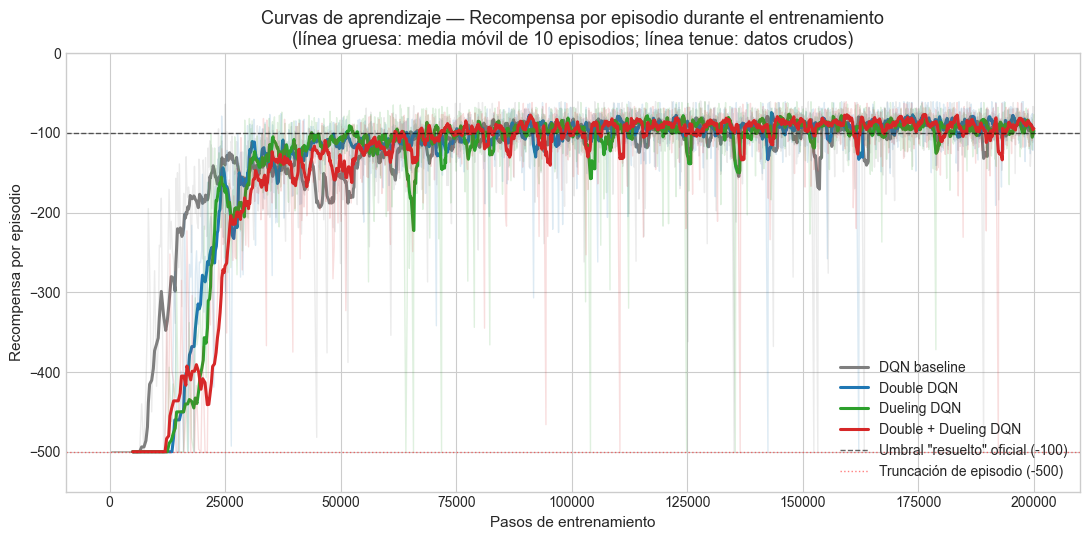

In [16]:
# Gráfica de las curvas de aprendizaje (recompensa por episodio)
fig, ax = plt.subplots(figsize=(11, 5.5))

W = 10  # Tamaño de ventana para el suavizado de la curva

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    rewards = np.asarray(log['episode_reward'])
    
    # Curva con crudos
    ax.plot(steps, rewards, color=meta['color'], alpha=0.15, linewidth=1)
    
    # Curva suavizada de la tendencia
    if len(rewards) >= W:
        smoothed = smooth(rewards, W)
        steps_smooth = steps[W-1:]
        ax.plot(steps_smooth, smoothed, color=meta['color'],
                linewidth=2.2, label=meta['label'])

# Líneas de referencia
ax.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Umbral "resuelto" oficial (-100)')
ax.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Truncación de episodio (-500)')

# Ejes y leyenda
ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Recompensa por episodio')
ax.set_title('Curvas de aprendizaje — Recompensa por episodio durante el entrenamiento\n(línea gruesa: media móvil de 10 episodios; línea tenue: datos crudos)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_ylim(-550, 0)

plt.tight_layout()
plt.savefig('plots/01_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

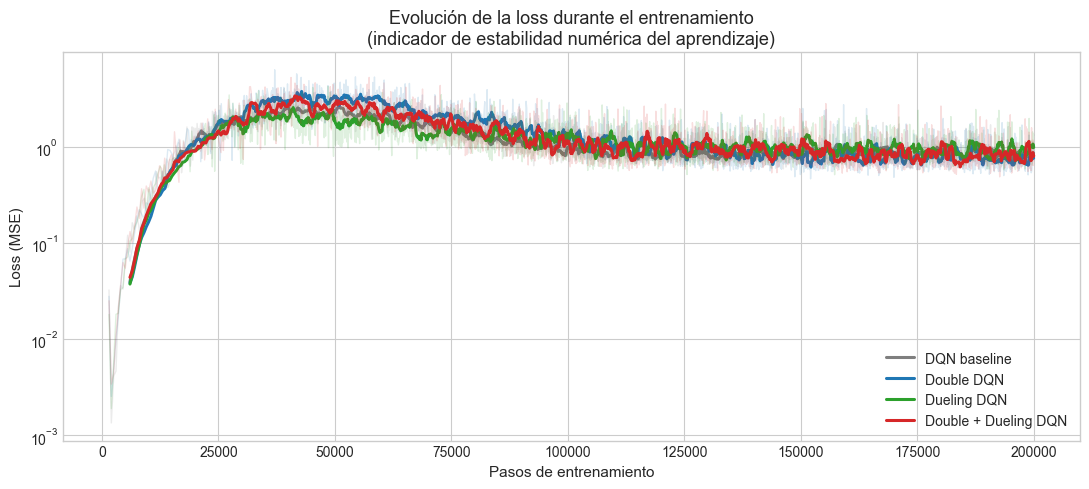

In [17]:
# Gráfica de la evolución de la loss durante el entrenamiento
fig, ax = plt.subplots(figsize=(11, 5))

W = 10 # Tamaño de ventana para el suavizado de la curva

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    losses = np.asarray(log['loss'])
    
    # Filtramos posibles NaN que pudieran aparecer en los primeros episodios antes del warmup
    mask = ~np.isnan(losses)
    steps_v, losses_v = steps[mask], losses[mask]
    
    # Curva original
    ax.plot(steps_v, losses_v, color=meta['color'], alpha=0.15, linewidth=1)

    # Curva suavizada por media móvil
    if len(losses_v) >= W:
        ax.plot(steps_v[W-1:], smooth(losses_v, W), color=meta['color'], linewidth=2.2, label=meta['label'])

# Ejes y leyenda
ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Evolución de la loss durante el entrenamiento\n(indicador de estabilidad numérica del aprendizaje)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_yscale('log')  # Escala logarítmica dado que la loss crece varios órdenes de magnitud

plt.tight_layout()
plt.savefig('plots/02_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

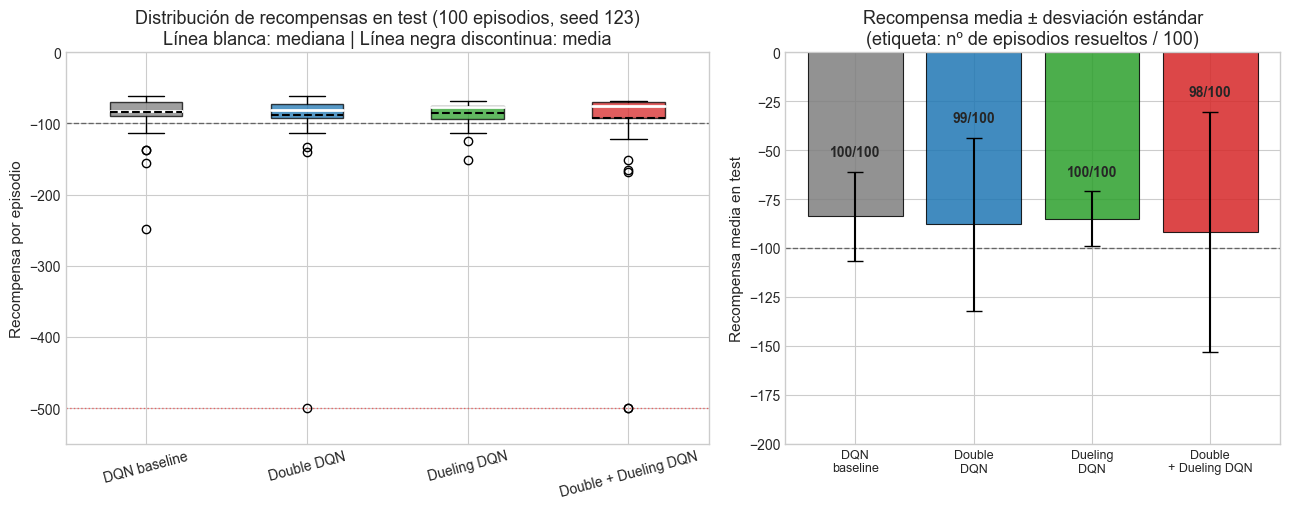

In [ ]:
# Gráfica de la distribución de recompensas en los 100 episodios de test
fig, (ax_box, ax_bar) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [1.3, 1]})

# Boxplot - Recompensas por cada configuración
data_test = {
    'baseline': rewards_baseline,
    'double': rewards_double,
    'dueling': rewards_dueling,
    'double_dueling': rewards_double_dueling,
}

# Etiquetas colores y valores
labels = [CONFIGS[c]['label'] for c in data_test]
colors = [CONFIGS[c]['color']  for c in data_test]
values = [data_test[c] for c in data_test]

bp = ax_box.boxplot(values, labels=labels, patch_artist=True, showmeans=True, meanline=True, meanprops={'color': 'black', 'linewidth': 1.5, 'linestyle': '--'}, medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax_box.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_box.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5)

# Ejes
ax_box.set_ylabel('Recompensa por episodio')
ax_box.set_title('Distribución de recompensas en test (100 episodios, seed 123)\nLínea blanca: mediana | Línea negra discontinua: media')
ax_box.tick_params(axis='x', rotation=15)
ax_box.set_ylim(-550, 0)

# Resumen estadístico - Métricas principales
means     = [v.mean() for v in values]
stds      = [v.std()  for v in values]
solved    = [int(np.sum(v > -500)) for v in values]

x = np.arange(len(labels))

# Barras con la media y desviación estándar
bars = ax_bar.bar(x, means, yerr=stds, color=colors, alpha=0.85, capsize=6, edgecolor='black', linewidth=0.8)
ax_bar.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([CONFIGS[c]['label'].replace(' ', '\n', 1) for c in data_test], fontsize=9)

# Ejes
ax_bar.set_ylabel('Recompensa media en test')
ax_bar.set_title('Recompensa media ± desviación estándar\n(etiqueta: nº de episodios resueltos / 100)')
ax_bar.set_ylim(-200, 0)

# Episodios resueltos
for bar, m, s, sv in zip(bars, means, stds, solved):
    ax_bar.text(bar.get_x() + bar.get_width()/2, m + s + 8, f'{sv}/100', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_test_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
#### Justificación de los parámetros seleccionados y de los resultados obtenidos
---
En esta sección se justifican las decisiones de diseño del agente y se analizan los resultados obtenidos en las distintas variantes evaluadas.

**Arquitectura de la red neuronal**

El estado de Acrobot es un vector de 6 valores continuos (coseno y seno de los dos ángulos, más sus velocidades angulares). Dado que no se trabaja con imágenes, no empleamos arquitecturas convolucionales, sino un perceptrón multicapa (MLP) con estructura 6 -> 128 -> 128 -> 3: dos capas ocultas de 128 neuronas (activación ReLU), y una capa de salida lineal que produce un Q-valor por cada acción posible.

Se eligió el tamaño de 128 neuronas a partir de la búsqueda de hiperparámetros. Con  el tamaño de 64 se alcanzaban buenos resultados pero 128 permitió mejorar la convergencia. Cabe señalar que la última capa densa de la salida (layers[-2]) se deja explícita en el código porque keras-rl2 la utiliza como punto de conexión para las cabezas V(s) y A(s,a) cuando se activa la arquitectura Dueling.

El `AcrobotProcessor` normaliza las velocidades angulares al rango [-1, 1] para facilitar el aprendizaje.

**Justificación de los hiperparámetros principales**

- **Factor de descuento γ = 0.99.** Acrobot penaliza cada paso con -1 hasta alcanzar la meta o llegar a 500 pasos. Un γ alto es de gran utilidad para que el agente valore correctamente a largo plazo. Las acciones al principio del episodio influyen completamente en si el agente logra alcanzar la altura final, pero su recompensa inmediata es la misma (-1) que la de cualquier otro paso.

- **Exploración ε-greedy con annealing lineal.** Empezamos con ε = 1.0 (exploración total) y decrecemos linealmente a ε = 0.05 durante los primeros 10.000 pasos de entrenamiento. En test, usamos ε = 0.0 (política greedy pura). Esto se traduce en una exploración inicial del agente y a medida que avanza el entrenamiento, va explotando cada vez más el conocimiento que ha aprendido.

- **Red objetivo con soft update τ = 1e-2.** La red target cambia lentamente, haciendo que los valores objetivo sean estables y evitando que la red principal "persiga su propia sombra" durante el bootstrap.

- **Experience replay de 200.000 transiciones, batch = 64, warmup = 1.000.** El replay permite reutilizar experiencias anteriores (que están altamente correlacionadas), reduciendo la varianza del gradiente. El warmup llena parcialmente el buffer antes de empezar el entrenamiento.

- **Optimizador Adam con lr = 1e-3, entrenamiento de 200.000 pasos.** Estos valores fueron determinados a través de la búsqueda de hiperparámetros.

- **BestCheckpointCallback.** Cada 40.000 pasos se evalúa el agente sobre 30 episodios de test y en caso de que hayan superado al mejor resultado observado hasta entonces, se guardan los pesos. A partir de este mecanismo se conserva el modelo que obtiene el mejor rendimiento durante el enrenamiento, lo cual es de gran utilidad para mitigar posibles deterioros del rendimiento en las últimas iteraciones.

**Búsqueda de hiperparámetros sobre el baseline**

Se han diseñado y probado cinco configuraciones distintas (trials) para optimizar y estudiar como afectaban algunas hiperparámetros en el rendimiento del agente. Cada trial es una modificación de uno o varios parámetros respecto a la configuración base, de forma que se pueda observar su infuelncia en el resultado:

| Trial | red | lr | batch | pasos | Recompensa media | Resueltos |
|---|---|---|---|---|---|---|
| B0 (referencia) | 64 | 1e-3 | 32 | 100k | -144.9 ± 99.9 | 94/100 |
| B1 (red mayor) | 128 | 1e-3 | 32 | 100k | **-500.0 ± 0.0** | 0/100 |
| B2 (más pasos) | 64 | 1e-3 | 32 | 200k | -106.7 ± 45.3 | 100/100 |
| B3 (lr menor) | 128 | 5e-4 | 64 | 150k | **-500.0 ± 0.0** | 0/100 |
| **B4** | **128** | **1e-3** | **64** | **200k** | **-87.9 ± 19.8** | **100/100** |

Conclusiones de la búsqueda:

- **B4 ha obtenido los mejores resultados:** logra la mejor recompensa media (-87.9) con la menor desviación estándar y resuelve todos los 100 episodios de test.
- **B0 vs B2 (más pasos):** duplica los pasos de 100k a 200k y consigue una mejora sustancial (-144.9 -> -106.7). Al aumentar el número de pasos del entrenamiento se mejora el rendimiento del agenta al disponer de más experiencia para ajustar la función de valor.
- **B1 y B3 colapsan a 0/100** dado que una red más grande requiere más muestras de entrenamiento (B1 con solo 100k pasos no tiene suficientes datos), y un learning rate demasiado bajo (B3 con 5e-4) hace que el agente no escape del plateau inicial.
- A partir de estos resultados se demuestra que aumentar exclusivamente el tamaño de la red no es suficiente si el entrenamiento no dispone de pasos suficientes.

B4 fue la configuración con resultados más estables y consistentes, por lo que se ha utilizado como configuración base para el experimento principal.

**Las propuestas de mejora**

Todos los experimentos posteriores se ejecutaron con la misma semilla (SEED=123) para garantizar una comparativa justa. Comparamos DQN baseline con tres mejoras, usando siempre la configuración B4 (128 neuronas, lr=1e-3, batch=64, 200k pasos):

- **Double DQN.** Desacopla la acción seleccionada (red online) de su evaluación (red target), reduciendo de esta forma el sesgo optimista del operador max estándar de Q-learning.
- **Dueling DQN.** Separa la estimación de Q en dos componentes: V(s) (valor del estado) y A(s,a) (ventaja de la acción) y permite al agente aprender que en muchos estados las acciones producen cambios similares en el valor.
- **Double + Dueling.** Combinación de ambas técnicas.

**Resultados de las 4 configuraciones**

Evaluación sobre 100 episodios de test en modo greedy (SEED=123):

| Configuración | Recompensa media | min / max | Pasos medios | Resueltos |
|---|---|---|---|---|
| DQN baseline | -83.93 ± 22.80 | -248 / -61 | 84.9 | 100/100 |
| Double DQN | -87.91 ± 44.27 | -500 / -61 | 88.9 | 99/100 |
| **Dueling DQN** | **-85.09 ± 13.93** | **-151 / -69** | **86.1** | **100/100** |
| Double + Dueling | -91.84 ± 61.38 | -500 / -68 | 92.8 | 98/100 |

**Análisis de resultados:**

Todas las configuraciones **cumplen y superan el requisito** (recompensa media > -100). Las cuatro alcanzan la meta en la mayoría de episodios:

- **Baseline y Dueling resuelven los 100/100 episodios de test** sin fallos.
- **Double DQN y Double + Dueling tienen 1-2 episodios fallidos** (-500), indicando una mayor inestabilidad puntual en test.

El **baseline obtiene un rendimiento ligeramente mejor frente a las variantes Double**, a pesar de esperar lo contrario en base a la literatura de Double DQN. Esto sucede porque las mejoras algorítmicas (Double, Dueling) son especialmente valiosas en problemas complejos con recompensas no acotadas (como Atari), pero en problemas de control clásico bien acotados como Acrobot, el impacto marginal es pequeño.

**Dueling es el ganador robusto:** aunque su recompensa media (-85.09) es ligeramente inferior a la del baseline (-83.93), su desviación estándar es significativamente menor (13.93 vs 22.80), su peor caso es mejor (-151 vs -248) y resuelve todos los episodios sin fallos.

**Visualización en las gráficas**

Las gráficas generadas (G01, G02, G03) permiten observar y comparar la evolución del entrenamiento entren las cuatro configuraciones:

- **Gráfica 1 (learning curves):** Todas las curvas convergen alrededor de -80 a -90 sin colapsos, indicando que la arquitectura y el presupuesto de 200k pasos son suficientes.
- **Gráfica 2 (loss):** La pérdida oscila alrededor de un equilibrio durante el entrenamiento. Aunque fluctúa, esto es normal en DQN porque el objetivo (red target) no es estacionario.
- **Gráfica 3 (distribución en test):** Los box plots muestran cajas estrechas para baseline y Dueling (convergencia consistente), mientras que Double DQN y Double + Dueling tienen cajas más anchas con outliers en -500 (episodios fallidos ocasionales).

**Vídeos de evolución**

Los vídeos generados muestran la política aprendida en 5 snapshots del entrenamiento (40k, 80k, 120k, 160k, 200k pasos) más el mejor modelo final (best checkpoint):

- **Baseline:** mejora progresiva y estable a lo largo del entrenamiento (-111 en 40k -> -76 en 120k -> -94 al final).
- **Double DQN:** inicialmente el rendimiento es inferior (-500 en 40k, por la corrección del sesgo optimista) pero luego mejora (-69 en 160k).
- **Dueling DQN:** curva más estable, todos los checkpoints entre -80 y -90 desde el paso 40k.
- **Double + Dueling:** en el checkpoint 80k hay una caída de rendimiento (-500), aunque el agente vuelve a recuperarse (-75 en 120k).

**Conclusión y modelo entregado**

A partir de los resultados obtenidos, Dueling DQN es la variante más estable y consistente. Presenta menor varianza, ausencia de episodios truncados y 100/100 episodios resueltos. Por ello, se selecciona como modelo final del proyecto. Los pesos del mejor checkpoint se proporcionan en `weights/dqn_dueling_best.h5f`.

**Limitaciones y posibles mejoras futuras**

- **Evaluación multi-semilla:** El análisis usa una única semilla (SEED=123) para test. Repetir con 3-5 semillas permitiría confirmar que las diferencias entre las configuraciones se mantienen de forma consistente.
- **Prioritized Experience Replay:** Podría mejorar la eficiencia de muestreo, especialmente en configuraciones como Double + Dueling donde el ruido limita el rendimiento.
- **Análisis de n-step returns:** Aumentar el horizonte de los returns podría acelerar la convergencia en problemas con recompensas tan escasas como Acrobot.
- **Exploración de Boltzmann:** Una alternativa al ε-greedy que podría ser más eficaz en espacios de acción pequeños.